In [1]:
# Define column header categories
identifiers = ['patientunitstayid', 'uniquepid', 'hospitalid']
demographics = ['gender', 'age', 'ethnicity']
measurements = ['admissionheight', 'admissionweight', 'bp', 'sao2', 'heartrate', 'respiration']
diagnoses = ['sepsis', 'pneumonia', 'bronchitis', 'diabetes', 'respiratory failure']
treatments = ['ventilation', 'insulin', 'intravenous fluid', 'antibacterials', 'penicillins', 'vancomycin']
admission_info = ['unitstaytype', 'admissionDx_cat', 'admissionDx_str', 'operative', 'or_within_4hrs',
                  'non_operative_organs', 'operative_organs', 'elective']
status = ['mortality']

# LOAD THE DATA IN A READABLE FORMAT
import numpy as np
import pandas as pd 

readable_data = pd.read_csv("out/processed_data/preprocessed.csv")

# process booleans
readable_data[diagnoses + treatments] = readable_data[diagnoses + treatments].fillna(False)
readable_data['unitstaytype'] = readable_data['unitstaytype'].astype('category')
readable_data['admissionDx_cat'] = readable_data['admissionDx_cat'].astype('category')

# bin continuous values
readable_data['age'] = readable_data['age'].map(lambda x: 90 if x=='> 89' else x)
readable_data['age'] = pd.to_numeric(readable_data['age'], errors='coerce')

fill_mean_cols = ['age', 'admissionheight', 'admissionweight', 'bp', 'sao2', 'heartrate','respiration']
readable_data[fill_mean_cols] = readable_data[fill_mean_cols].fillna(readable_data[fill_mean_cols].mean())
column_bins = {
    "age": {"bins":[-np.inf, 60, np.inf], "labels":["young", "old"]},
    "sao2": {"bins":[-np.inf, 95, np.inf], "labels":["low", "healthy"]},
    "heartrate": {"bins":[-np.inf, 60, 100, np.inf], "labels":["low", "healthy", "high"]},
    "respiration": {"bins":[-np.inf, 18, np.inf], "labels":["healthy", "high"]},
    "bp": {"bins":[-np.inf, 70, 100, np.inf], "labels":["low", "healthy", "high"]},
    "admissionheight": {"bins":[-np.inf, 170, np.inf], "labels":["short", "tall"]},
    "admissionweight": {"bins":[-np.inf, 80, np.inf], "labels":["light", "heavy"]}
}

for col, bins in column_bins.items():
    readable_data[col] = pd.cut(readable_data[col], **bins)

readable_data

/var/folders/gq/nr1qyp1s0f76pz81bn_6vlzc0000gq/T/ipykernel_24012/907168153.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  readable_data[diagnoses + treatments] = readable_data[diagnoses + treatments].fillna(False)


,patientunitstayid,uniquepid,hospitalid,gender,age,ethnicity,admissionheight,admissionweight,unitstaytype,mortality,...,ventilation,insulin,intravenous fluid,antibacterials,penicillins,vancomycin,bp,sao2,heartrate,respiration
0,141168,002-34851,59,Female,old,Caucasian,short,heavy,admit,True,...,False,False,False,False,False,False,low,low,high,high
1,141178,002-33870,60,Female,young,Caucasian,short,light,admit,False,...,False,False,False,False,False,False,healthy,low,healthy,high
2,141179,002-33870,60,Female,young,Caucasian,short,heavy,stepdown/other,False,...,False,False,False,False,False,False,healthy,healthy,healthy,high
3,141194,002-5276,73,Male,old,Caucasian,tall,light,admit,False,...,False,False,False,False,False,False,low,healthy,healthy,high
4,141196,002-37665,67,Male,old,Caucasian,short,heavy,stepdown/other,False,...,False,False,False,False,False,False,healthy,healthy,healthy,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182716,3353235,035-16382,458,Male,young,Caucasian,tall,heavy,admit,False,...,False,False,False,False,False,False,high,healthy,healthy,high
182717,3353237,035-751,458,Female,old,Caucasian,short,light,admit,False,...,False,False,False,False,False,False,high,low,healthy,high
182718,3353251,035-5166,458,Male,old,African American,tall,heavy,admit,False,...,True,True,False,False,False,False,healthy,healthy,healthy,high
182719,3353254,035-19511,459,Male,old,Caucasian,tall,heavy,admit,False,...,False,False,True,False,False,False,healthy,healthy,healthy,high


In [44]:
# processed_num = pd.read_csv("out/processed_data/processed_num.csv")
# cohort = processed_num['patientunitstayid']

preprocessed = pd.read_csv("out/processed_data/preprocessed.csv")
# preprocessed = preprocessed[preprocessed['patientunitstayid'].isin(cohort)]

keep = ['patientunitstayid', 'uniquepid', 'hospitalid', 
        'gender', 'age', 'ethnicity', 
        'sepsis', 'pneumonia', 'bronchitis', 'diabetes', 'respiratory failure',
        'ventilation', 'insulin', 'intravenous fluid', 'antibacterials',
        'penicillins', 'vancomycin', 'bp', 'sao2', 'heartrate', 
        'mortality']

filter_out_na = ['age', 'ethnicity', 'sepsis', 'ventilation']
preprocessed = preprocessed.dropna(subset=filter_out_na)[keep].reset_index(drop=True)
preprocessed

,patientunitstayid,uniquepid,hospitalid,gender,age,ethnicity,sepsis,pneumonia,bronchitis,diabetes,...,ventilation,insulin,intravenous fluid,antibacterials,penicillins,vancomycin,bp,sao2,heartrate,mortality
0,242040,003-49775,92,Male,78,Caucasian,False,True,False,False,...,True,True,False,True,True,True,81.948718,93.487976,89.20548,False
1,242070,003-53430,79,Female,68,Caucasian,False,False,False,False,...,True,False,False,False,False,False,84.888889,96.348120,83.98635,False
2,242082,003-56172,108,Male,75,Caucasian,True,False,False,False,...,False,False,True,True,False,False,68.424528,93.957810,72.13333,False
3,242083,003-7975,92,Female,> 89,Caucasian,False,False,False,False,...,True,False,True,True,False,False,68.750000,96.848180,61.89404,False
4,242154,003-8066,79,Female,46,Caucasian,False,True,False,False,...,True,False,False,True,True,True,88.250000,94.562000,104.73639,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139087,3353235,035-16382,458,Male,50,Caucasian,False,False,False,False,...,False,False,False,False,False,False,108.090909,95.198110,87.08962,False
139088,3353237,035-751,458,Female,79,Caucasian,False,False,False,False,...,False,False,False,False,False,False,102.173913,94.637100,91.04016,False
139089,3353251,035-5166,458,Male,73,African American,True,True,False,False,...,True,True,False,False,False,False,81.422414,95.798065,80.11895,False
139090,3353254,035-19511,459,Male,81,Caucasian,False,False,False,False,...,False,False,True,False,False,False,85.764706,98.321430,76.17857,False


In [52]:
# PROCESS THE DATAFRAME
# processed = preprocessed[identifiers + demographics + ['unitstaytype'] + measurements + diagnoses + treatments + status].copy()
processed = preprocessed.copy()


# all cols to numeric
processed['age'] = processed['age'].map(lambda x: 90 if x=='> 89' else x)
processed['age'] = pd.to_numeric(processed['age'], errors='coerce')

processed['gender'] = processed['gender'] == 'Male'
processed['ethnicity'] = processed['ethnicity'] == 'Caucasian'
bool_cols = ['gender', 'ethnicity'] + diagnoses + treatments + status
processed[bool_cols] = processed[bool_cols].astype(int)

fill_mean_cols = ['bp', 'sao2', 'heartrate']
processed[fill_mean_cols] = processed[fill_mean_cols].fillna(processed[fill_mean_cols].mean())
column_bins = {
    "age": {"bins":[-np.inf, 60, np.inf], "labels":["young", "old"]},
    "sao2": {"bins":[-np.inf, 95, np.inf], "labels":["low", "healthy"]},
    "heartrate": {"bins":[-np.inf, 60, 100, np.inf], "labels":["low", "healthy", "high"]},
    "bp": {"bins":[-np.inf, 70, 100, np.inf], "labels":["low", "healthy", "high"]}
}
for col, bins in column_bins.items():
    processed[col] = pd.cut(processed[col], **bins)

processed[list(column_bins)] = processed[list(column_bins)].apply(lambda x: x.cat.codes)
processed



,patientunitstayid,uniquepid,hospitalid,gender,age,ethnicity,sepsis,pneumonia,bronchitis,diabetes,...,ventilation,insulin,intravenous fluid,antibacterials,penicillins,vancomycin,bp,sao2,heartrate,mortality
0,242040,003-49775,92,1,1,1,0,1,0,0,...,1,1,0,1,1,1,1,0,1,0
1,242070,003-53430,79,0,1,1,0,0,0,0,...,1,0,0,0,0,0,1,1,1,0
2,242082,003-56172,108,1,1,1,1,0,0,0,...,0,0,1,1,0,0,0,0,1,0
3,242083,003-7975,92,0,1,1,0,0,0,0,...,1,0,1,1,0,0,0,1,1,0
4,242154,003-8066,79,0,0,1,0,1,0,0,...,1,0,0,1,1,1,1,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139087,3353235,035-16382,458,1,0,1,0,0,0,0,...,0,0,0,0,0,0,2,1,1,0
139088,3353237,035-751,458,0,1,1,0,0,0,0,...,0,0,0,0,0,0,2,0,1,0
139089,3353251,035-5166,458,1,1,0,1,1,0,0,...,1,1,0,0,0,0,1,1,1,0
139090,3353254,035-19511,459,1,1,1,0,0,0,0,...,0,0,1,0,0,0,1,1,1,0


In [58]:
(processed == 1).mean() * 100

patientunitstayid       0.000000
uniquepid               0.000000
hospitalid              0.000000
gender                 53.890231
age                    60.469330
ethnicity              76.458747
sepsis                 12.290426
pneumonia              12.447876
bronchitis              0.338625
diabetes                3.250367
respiratory failure    23.977655
ventilation            47.403158
insulin                18.570443
intravenous fluid      32.871768
antibacterials         28.816179
penicillins             5.004601
vancomycin              6.433871
bp                     74.251574
sao2                   81.999684
heartrate              82.012625
mortality               4.586892
dtype: float64

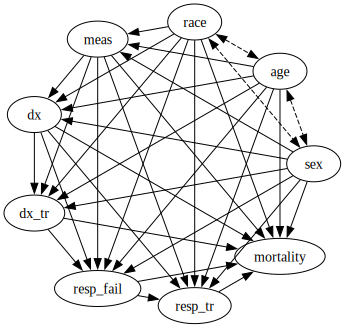

In [243]:
from src.parser import *
from src.utils import *
from src.data import * 
from src.model import FF_NCM

config = eICUConfigParser.get_parser(config='thu2')
graph = get_graph_from_config(config)
processed_dt = ProcessedData(processed, assignments=config.assignments)
# print(processed_dt.data.head(5))
graph.plot(2)


In [76]:
# processed_dt.data['hospitalid'].value_counts()
# processed_dt.data[processed_dt.data['hospitalid'].isin(get_hospitals_with('all'))]
hospitals = set(processed_dt.data['hospitalid'].unique())
all_hosp = set(get_hospitals_with('all'))
print(hospitals - all_hosp)
print(all_hosp - hospitals)
processed_dt.data[processed_dt.data['hospitalid'].isin(get_hospitals_with('all'))]['hospitalid'].value_counts()

{136, 123}
{361, 91}


hospitalid
264    4416
338    3996
243    3811
443    3410
300    3295
       ... 
85        2
86        1
423       1
151       1
421       1
Name: count, Length: 191, dtype: int64

In [245]:
from src.train import *
from sklearn.model_selection import train_test_split

batch_size = 256
train_df, test_df = train_test_split(
    pd.concat(processed_dt.hosp_data.values(), axis=0),
    test_size=0.1
)
train_dataloader = NCMDataset(train_df, config.assignments).get_dataloader(batch_size=batch_size)
test_dataloader = NCMDataset(test_df, config.assignments).get_dataloader(batch_size=batch_size)
# train_df, test_df, train_dataloader, test_dataloader = processed_dt.train_test_split(
#     train_hospitals=[264],
#     batch_size=batch_size
# )

retrain = False
ncm = FF_NCM.load(
    path="thu2_3epochREDO",
    cg=graph,
    v_size={k:len(v) for k,v in config.assignments.items()},
    scale=processed_dt.get_assigned_scale()
)
if retrain:
    _ = train_ncm(ncm, train_dataloader, hyperparameters={'n-epochs': 3})
    ncm.save("out/models/thu2_3epoch_hosp264REDO.pth")

compute_accuracy(
    ncm,
    test_dataloader,
    "mortality"
)

Train epoch 1: 100%|██████████| 489/489 [02:12<00:00,  3.68it/s, loss=0.00225]


Epoch 1/3, Loss: 0.0503


Train epoch 2: 100%|██████████| 489/489 [02:10<00:00,  3.73it/s, loss=0.00213]


Epoch 2/3, Loss: 0.0170


Train epoch 3: 100%|██████████| 489/489 [02:10<00:00,  3.74it/s, loss=0.00167]


Epoch 3/3, Loss: 0.0145
Model saved to out/models/thu2_3epochREDO.pth


Computing  accuracy: 100%|██████████| 55/55 [00:13<00:00,  3.97it/s]

		 energy-based: 0.9857
		 js-divergence: 0.9341


tensor(0.9837, device='mps:0')

In [246]:
from src.metric import *

outcome_vals = {
    'actual': 1,
    'whatif': 0
}
treatment_vals = {
    'actual': 0,
    'whatif': 1
}

pnps(ncm, 'mortality', outcome_vals, "resp_tr", treatment_vals)

0.1423: probability that mortality=0 if we had intervened to make resp_tr=1, given that mortality was actually 1 and resp_tr was actually 0.


0.1422680412371134

In [111]:
any_other_hospital = pd.concat(
    [processed_dt.hosp_data[h] for h in processed_dt.hosp_data if h != 264],
    axis=0
)

compute_accuracy(
    ncm,
    NCMDataset(any_other_hospital, processed_dt.assignments).get_dataloader(batch_size=128),
    "resp_fail"
)

Computing  accuracy:   0%|          | 0/1053 [00:00<?, ?it/s]

Computing  accuracy: 100%|██████████| 1053/1053 [02:18<00:00,  7.61it/s]

		 energy-based: 0.9809
		 js-divergence: 0.9703


tensor(0.9773, device='mps:0')

In [83]:
any_other_hospital.groupby(['ethnicity', 'age', 'gender'])[[ "respiratory failure"]].mean() * 100

respiratory failure
ethnicity age gender                     
0.0       0.0 0.0               21.785069
              1.0               22.076769
          1.0 0.0               28.435959
              1.0               27.411477
1.0       0.0 0.0               23.082560
              1.0               21.580916
          1.0 0.0               25.187539
              1.0               24.065474

In [104]:
same_test = processed_dt.data[(~processed_dt.data.index.isin(train_df.index)) & (processed_dt.data['hospitalid']==264)]
same_test = same_test[processed_dt.columns]
same_test

,ethnicity,age,gender,bp,sao2,heartrate,pneumonia,sepsis,intravenous fluid,antibacterials,respiratory failure,ventilation,mortality
59428,1.0,1.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,1.0,1.0,1.0
59445,1.0,1.0,1.0,0.5,0.0,0.5,1.0,0.0,1.0,0.0,0.0,1.0,0.0
59446,1.0,1.0,1.0,0.5,0.0,0.5,1.0,0.0,1.0,1.0,0.0,0.0,0.0
59464,1.0,1.0,0.0,0.5,1.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59465,1.0,0.0,0.0,0.5,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66214,0.0,0.0,0.0,0.5,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66215,0.0,0.0,1.0,1.0,1.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66221,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66222,1.0,1.0,1.0,0.5,1.0,0.5,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [109]:
compute_accuracy(
    ncm,
    NCMDataset(same_test, processed_dt.assignments).get_dataloader(batch_size=128),
    "resp_fail"
)

Computing  accuracy: 100%|██████████| 4/4 [00:00<00:00,  8.44it/s]


		 energy-based: 0.9903
		 js-divergence: 0.9921


tensor(0.9796, device='mps:0')

In [120]:
from src.metric import * 

demos = ['race', 'sex', 'age']
old_moc_dict = {'race': 0, 'sex': 1, 'age': 1}
Y = "resp_fail"

old_moc = CTFTerm(demos, {}, old_moc_dict)
py1 = CTFTerm({Y}, {}, {Y: 1})
py1_oldmoc = CTF({py1}, {old_moc})

py1_oldmoc_ncm = ncm.compute_ctf(py1_oldmoc, n=100_000, evaluating=True)
py1_oldmoc_ncm

nan

In [122]:
probability(ncm, Y, 1)

0.1745

In [118]:
from sklearn.ensemble import RandomForestClassifier

features = ['ethnicity','age', 'gender',
 'bp',
 'sao2',
 'heartrate',
 'pneumonia',
 'sepsis',
 'intravenous fluid',
 'antibacterials',
 'respiratory failure',
 'ventilation']
X_train = train_df[features]
y_train = train_df['mortality']
X_test, y_test = test_df[features], test_df['mortality']

# Initialize model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [211]:
from sklearn.metrics.pairwise import rbf_kernel

def compute_mmd(x, y, gamma=1.0):
    Kxx = rbf_kernel(x, x, gamma=gamma)
    Kyy = rbf_kernel(y, y, gamma=gamma)
    Kxy = rbf_kernel(x, y, gamma=gamma)
    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

def sample_from_proba(probs, n_samples=1):
    N, K = probs.shape
    samples = np.zeros((N, n_samples), dtype=int)

    for i in range(N):
        samples[i] = np.random.choice(K, size=n_samples, p=probs[i])

    return samples

def true_to_samples(y_true, n_samples=1):
    return np.repeat(y_true[:, None], n_samples, axis=1)

probs = rf.predict_proba(same_test[features])
rf_samples = sample_from_proba(probs)
true_samples = true_to_samples(same_test['mortality'].to_numpy())

x_flat = rf_samples.reshape(-1, 1)
y_flat = true_samples.reshape(-1, 1)
print(x_flat.shape, y_flat.shape)

n_batches = 15
x_batches = np.array_split(x_flat, n_batches) 
y_batches = np.array_split(y_flat, n_batches)
print(len(x_batches), x_batches[0].shape, y_batches[0].shape)

batch_size = 128

total_loss = 0
done=False
for idx in tqdm(range(n_batches)):
    labels = y_batches[idx]
    pred_labels = x_batches[idx]
    mmd = compute_mmd(labels, pred_labels)
    total_loss += mmd 

total_loss

(442, 1) (442, 1)
15 (30, 1) (30, 1)


100%|██████████| 15/15 [00:00<00:00, 1962.83it/s]


0.03649746685417665

In [215]:
1- (total_loss)

0.9635025331458233

In [205]:
def get_distribution_diffs(model, dataloader, target_var, device=DEVICE, label=""):
    model.eval()
    total_loss = 0
    with T.no_grad():
        pbar = tqdm(dataloader, desc=f"Computing {label} accuracy")
        for batch in pbar:
            batch = {k: v.to(device) for k, v in batch.items()}
            batch_size = next(iter(batch.values())).shape[0]

            preds=model(n=batch_size,select={target_var})[target_var]
            # labels = batch[target_var]
            
            labels = T.cat([batch[target_var]], axis=1)
            pred_labels = T.cat([preds], axis=1)
            total_loss += compute_mmd(labels.cpu(),pred_labels.cpu())


    return total_loss/len(dataloader)

1 - get_distribution_diffs(
    ncm,
    NCMDataset(same_test, processed_dt.assignments).get_dataloader(batch_size=128),
    "mortality"
)

Computing  accuracy: 100%|██████████| 4/4 [00:00<00:00,  8.64it/s]


0.9474447667598724

In [237]:
test_df.groupby(['ethnicity',	'age',	'gender']).mean(numeric_only=True)

bp      sao2  heartrate  pneumonia    sepsis  \
ethnicity age gender                                                       
0.0       0.0 0.0     0.506873  0.922660   0.601291   0.091919  0.117051   
              1.0     0.540532  0.900000   0.580731   0.096899  0.102658   
          1.0 0.0     0.454212  0.886573   0.541998   0.126058  0.141847   
              1.0     0.475613  0.891233   0.537495   0.139617  0.149006   
1.0       0.0 0.0     0.455839  0.835147   0.588779   0.114826  0.121999   
              1.0     0.508323  0.809098   0.566078   0.107331  0.100847   
          1.0 0.0     0.418271  0.790799   0.548157   0.138597  0.134747   
              1.0     0.446046  0.782270   0.531127   0.143220  0.129935   

                      intravenous fluid  antibacterials  respiratory failure  \
ethnicity age gender                                                           
0.0       0.0 0.0              0.364621        0.285754             0.217578   
              1.0              0.341971        0.253599             0.220819   
          1.0 0.0              0.322976        0.330176             0.284199   
              1.0              0.318985        0.340202             0.273991   
1.0       0.0 0.0              0.366786        0.279618             0.230746   
              1.0              0.342463        0.256956             0.215921   
          1.0 0.0              0.320033        0.303034             0.251615   
              1.0              0.310497        0.294497             0.240558   

                      ventilation  mortality  
ethnicity age gender                          
0.0       0.0 0.0        0.397390   0.033602  
              1.0        0.438095   0.035437  
          1.0 0.0        0.513326   0.050019  
              1.0        0.515059   0.055481  
1.0       0.0 0.0        0.438514   0.031123  
              1.0        0.464166   0.036729  
          1.0 0.0        0.489005   0.053997  
              1.0        0.508971   0.053911

In [240]:
train_df[train_df['mortality']==1][['ethnicity',	'age',	'gender']].value_counts()

ethnicity  age  gender
1.0        1.0  1.0       62
                0.0       51
           0.0  0.0       20
                1.0       12
0.0        1.0  1.0        5
           0.0  1.0        3
           1.0  0.0        1
Name: count, dtype: int64

In [119]:
from sklearn.metrics import accuracy_score
# Make predictions
y_pred = rf.predict(any_other_hospital[features])

# Calculate and print accuracy
accuracy = accuracy_score(any_other_hospital['mortality'], y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 95.06%


In [116]:
rf_features = ['ethnicity','age', 'gender',
 'bp',
 'sao2',
 'heartrate',
 'pneumonia',
 'sepsis',
 'intravenous fluid',
 'antibacterials',]
X_train_rf, y_train_rf = train_df[rf_features], train_df['respiratory failure']

# Initialize model
rf_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_rf.fit(X_train_rf, y_train_rf)

y_pred = rf_rf.predict(same_test[rf_features])
accuracy = accuracy_score(same_test['respiratory failure'], y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 76.47%


In [227]:

probs = rf_rf.predict_proba(any_other_hospital[rf_features])
rf_samples = sample_from_proba(probs)
true_samples = true_to_samples(any_other_hospital['respiratory failure'].to_numpy())

x_flat = rf_samples.reshape(-1, 1)
y_flat = true_samples.reshape(-1, 1)
print(x_flat.shape, y_flat.shape)

n_batches = 4000
x_batches = np.array_split(x_flat, n_batches) 
y_batches = np.array_split(y_flat, n_batches)
print(len(x_batches), x_batches[0].shape, y_batches[0].shape)

total_loss = 0
for idx in tqdm(range(n_batches)):
    labels = y_batches[idx]
    pred_labels = x_batches[idx]
    mmd = compute_mmd(labels, pred_labels)
    total_loss += mmd 

total_loss

(134676, 1) (134676, 1)
4000 (34, 1) (34, 1)


100%|██████████| 4000/4000 [00:01<00:00, 3939.64it/s]


118.57529906806063

In [228]:
1 - (total_loss/2000)

0.9407123504659697

In [166]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from src.metric.divergence import *

torch.manual_seed(0)
class SimpleNN(nn.Module):
    def __init__(self, n_feats):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_feats, 16),
            nn.ReLU(),
            nn.Linear(16, 2)  # 2 output classes (logits)
        )

    def forward(self, x):
        return self.net(x)  # raw logits

model = SimpleNN(len(features))
criterion = nn.CrossEntropyLoss()  # handles softmax internally
optimizer = optim.Adam(model.parameters(), lr=0.01)

X_tr = torch.tensor(train_df.drop("mortality", axis=1).values, dtype=torch.float32)
y_tr = torch.tensor(train_df["mortality"].values, dtype=torch.float32)

for epoch in range(10):
    epoch_loss = 0
    optimizer.zero_grad()

    logits = model(X_tr)              # shape: (N, 2)
    loss = criterion(logits, y_tr.long())    # cross-entropy

    loss.backward()
    optimizer.step()

    if epoch % 2 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

preds = model(torch.tensor(test_df.drop("mortality", axis=1).values, dtype=torch.float32))
preds = torch.argmax(preds, dim=1)
y_true = torch.tensor(test_df["mortality"].values, dtype=torch.float32)
(preds == y_true).sum().item() / len(y_true)

Epoch 0, Loss: 0.8089
Epoch 2, Loss: 0.6955
Epoch 4, Loss: 0.5920
Epoch 6, Loss: 0.4894
Epoch 8, Loss: 0.3901


0.953921757278823

In [ ]:
import torch
import torch.nn as nn

class MLE_Net(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 2)  # outputs: mean and log_variance
        )

    def forward(self, x):
        out = self.net(x)
        mu = out[:, 0]
        log_var = out[:, 1]
        return mu, log_var


def gaussian_nll(y, mu, log_var):
    var = torch.exp(log_var)
    return torch.mean(
        0.5 * log_var + (y - mu)**2 / (2 * var)
    )


# Example training loop
model = MLE_Net(input_dim=1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(100):
    x = torch.randn(64, 1)
    y = 2 * x + torch.randn(64, 1) * 0.5

    mu, log_var = model(x)

    loss = gaussian_nll(y.squeeze(), mu, log_var)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [154]:
ex = torch.tensor([1,2,3,4,5])
b_size = 3
idx = 0
while idx < len(ex):
    print(ex[idx:idx+b_size])
    idx += b_size

tensor([1, 2, 3])
tensor([4, 5])


In [155]:
len(preds)/128

1055.609375

In [158]:
batch_size = 128
idx = 0

total_loss = 0
while idx < len(preds):
    labels = y_true[idx:idx+batch_size].unsqueeze(1).float()
    pred_labels = preds[idx:idx+batch_size].unsqueeze(1).float()

    loss = MMD_loss(labels,pred_labels)
    total_loss += loss
    idx += batch_size

    if (idx/batch_size) % 50 == 0:
        print(f"batch {idx/batch_size}: {loss/batch_size}")

batch 50.0: 0.00015705637633800507
batch 100.0: 0.00016677752137184143
batch 150.0: 0.00018986593931913376
batch 200.0: 0.00014854967594146729
batch 250.0: 0.00012303143739700317
batch 300.0: 0.00013518333435058594
batch 350.0: 0.00015705637633800507
batch 400.0: 0.00012424588203430176
batch 450.0: 0.00018986593931913376
batch 500.0: 0.00012424588203430176
batch 550.0: 0.00013032183051109314
batch 600.0: 0.00015705637633800507
batch 650.0: 0.0001230323687195778
batch 700.0: 0.0001485506072640419
batch 750.0: 0.00012667663395404816
batch 800.0: 0.00012424588203430176
batch 850.0: 0.00013032276183366776
batch 900.0: 0.00013032276183366776
batch 950.0: 0.000177714042365551
batch 1000.0: 0.0001485506072640419
batch 1050.0: 0.0002032322809100151


In [231]:
1-(19.8453 / 10000)

0.99801547

In [3]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

features = ['ethnicity', 'age', 'gender', 'admissionheight', 'admissionweight',
       'bp', 'sao2', 'heartrate', 'respiration', 'pneumonia', 'bronchitis',
       'sepsis', 'diabetes', 'intravenous fluid', 'antibacterials', 'insulin',
       'respiratory failure', 'ventilation', 'mortality']

dtrain = xgb.DMatrix(train_df[features], label=train_df['mortality'])

# model = xgb.XGBClassifier(n_estimators=10, max_depth=3, learning_rate=0.1, objective='multi:softmax')
# model.fit(train_df[features], train_df['mortality'])


: 

In [ ]:

# 3. Make predictions and evaluate
preds = model.predict(test_df[features])
print(f"Accuracy: {accuracy_score(test_df['mortality'], preds):.4f}")